# HW 3: STFT, Features, and Regression (15 points)

For each markdown cell, add a cell (or cells) of code below. 
Reminders:
* This is an individual assignment. 
* If you use GenAI tools to assist you with your homework, remember to fill out the GenAI Usage Statement at the bottom of the notebook. Even if you use GenAI, you should not be directly copying the code.
* You may only use functions/packages we have discussed in class

Read in the following files from your "audio" folder.
- /audio/country.00000.wav
- /audio/hiphop.00000.wav
    
Ensure that amplitudes are normalized to between -1 and 1. 

## Part 1: STFT parameters and visualization (6 points)

#### Write your own STFT (3 points)

Write your own STFT function that will output a 2D matrix with shape (num_frames, num_bins), where each row contains the DFT of a single frame.

* Use a hop size equal to half the frame size (i.e., hop_size = frame_size // 2) so that frames overlap by 50%, and you should apply a hanning window to each frame (you may use `np.hanning()` for this.)

* The user should be able to vary the size of the frame (leave hop_size fixed at 50%).

*Note: You should use the built in numpy FFT function (instead of your DFT). This means you will have to work in powers of 2!*

In [24]:
# your code here
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from numpy import fft
from scipy.fftpack import fftshift 
from IPython.display import Image, Audio
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.signal import stft
from scipy.io.wavfile import read
import math


def my_stft(audio_input, frame_size, sampling_rate = 44100):
    
    # Define frame_length (should be power of two based on input frame_size)
    if frame_size > 0 and math.log2(frame_size).is_integer():
        frame_length = frame_size
    else:
        return 'Frame size must be a power of 2.'

    # Define hop size is half the frame size
    hop_length = frame_size//2 # // = floor division

    # Define number of frames (m) we can extract with 50% overlap based on the total length of our signal
    # If the signal does not fit an integer number of frames, truncate
    audio_length = len(audio_input) - frame_length # remove 1 frame of the tail to avoid inaccurate data
    n_mbins = (audio_length // hop_length) + 1 # + 1 for DC offset

    # Define total number of frequency bins
    n_kbins = frame_length//2

    # Pre-allocate matrix for STFT. Remember it should be structured as [time_frames, frequency_bins]
    stft_matrix = np.zeros((n_mbins,n_kbins), dtype=complex)

    # Define window
    window = np.hanning(frame_length)

    # Iterate through signal by frame
    for m in range(n_mbins):
        # index into the frame, apply window, apply fft over the frame, store in matrix
        start = m * hop_length
        end = start + frame_length
        frame = audio_input[start:end] * window
        fft = np.fft.rfft(frame)
        stft_matrix[m, :] = fft[:n_kbins]

    return stft_matrix


#### Apply your STFT function

Apply your STFT function to the audio files listed above (country and hiphop)

In [30]:
(country_fs, x) = read('../audio/country.00000.wav')
country_matrix = my_stft(x, 128, country_fs)

(hiphop_fs, x) = read('../audio/hiphop.00000.wav')
hiphop_matrix = my_stft(x, 128, hiphop_fs)
hiphop_matrix

array([[-5.81017755e+04+0.00000000e+00j,  6.25183247e+04-9.16335116e+03j,
        -8.60119731e+04+3.95181405e+04j, ...,
        -2.86733035e+00-5.83612146e+00j,  2.76315293e-01+2.48946211e+00j,
         1.38443151e+00-2.08875967e-01j],
       [-4.15146406e+04+0.00000000e+00j,  3.21330159e+04-1.70865525e+04j,
        -3.40810888e+04-1.99639431e+04j, ...,
        -3.53028129e+00-4.47374983e+00j,  2.27241931e-01+2.09420952e+00j,
        -6.55314166e+00+9.52596999e-01j],
       [-6.39160628e+04+0.00000000e+00j,  3.82385257e+04+8.80448103e+03j,
        -5.05103650e+03+1.58756807e+04j, ...,
         1.32258649e+01-8.73086564e-01j,  2.23564832e-01-1.37039522e+00j,
        -2.88901105e+00-6.61546875e-01j],
       ...,
       [-1.49252624e+05+0.00000000e+00j,  7.81266875e+04-2.22417345e+04j,
         2.98666857e+04+1.03592978e+04j, ...,
        -7.78404289e+00+2.72886381e+01j,  8.16887303e+00-2.98539125e+00j,
         3.93028397e-01-7.42907065e-02j],
       [-1.10109693e+05+0.00000000e+00j,  4.

#### Write your own spectrogram function (3 points)

Write your own spectrogram function (using `plt.pcolormesh()`) called `plot_spectrogram()` that takes the complex-valued STFT output from your above function, and the sampling rate, and plots a magnitude spectrogram in decibels.

The axes should be properly labeled (time on x-axis, Frequency on y-axis).

*Note: audio processing workflows and dataframe logic in general in Python commonly use rows = time. However, several plotting functions like pcolormesh() annoyingly expect rows = frequency and columns = time. Therefore, we simply add a step to 'transpose' our 2d array or matrix in our code below.*


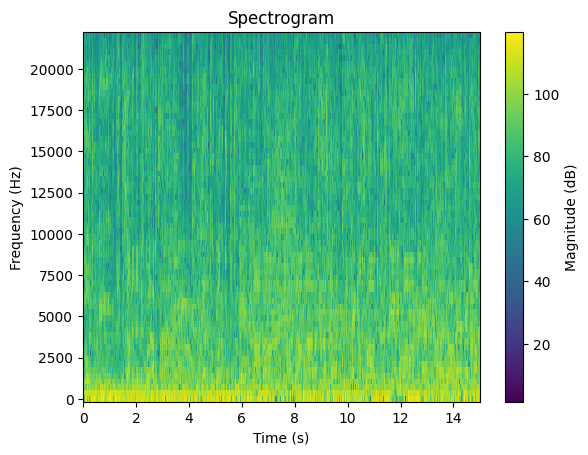

In [44]:
# your code here
def plot_spectrogram(stft_matrix, frame_size, sampling_rate):

    # Take magnitude and convert to decibels
    magnitude = np.abs(stft_matrix).T  # Transpose so rows = frequencies
    magnitude_db = 20 * np.log10(magnitude + 1e-6)  # avoid log(0)

    # Time and frequency axes
    num_frames =  np.size(stft_matrix, axis=0) # total number of frames, try np.size()
    hop_size = frame_size//2  # recall it was 50% of the frame size
    duration = (num_frames * hop_size) // sampling_rate   # find duration
    
    # Make a time axis by taking the total duration and dividing the timeline according to the number of frames:
    time_axis = np.linspace(0, duration, num_frames)
    # Ditto for frequency axis according to the number of bins
    freq_axis = np.linspace(0, sampling_rate // 2, np.size(stft_matrix, axis=1))

    # Plot only up to Nyquist frequency by indexing your magnitude vector
    plt.pcolormesh(time_axis,freq_axis, magnitude_db) 
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title("Spectrogram")
    plt.colorbar(label="Magnitude (dB)")
    plt.show()

    
    
plot_spectrogram(country_matrix, 128, 44100)

Plot the spectrogram of the country and hiphop audio files

## Part 2: Feature Extraction (4 points)

We will perform feature extraction and compare the two audio files above.

Extract the following features for each file (you may use librosa functions):
- RMSE
- Spectral Centroid
- Spectral Flux
- ZCR

For each feature:
- graph the results of each feature
- briefly describe what the feature might tell us perceptually
- briefly describe whether or not this might be a useful feature for classification (based on the graphs)

1 point for each correct feature calculation and associated explanation/reasoning

/var/folders/5w/y85sjccs33v6837lhls38j4r0000gn/T/ipykernel_23934/1928186951.py:25: FutureWarning: Pass y=[-5543.  -711.   641. ...  2511.  1269.  -690.] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  hiphop_rms = librosa.feature.rms(hiphop_x.astype(float))
/var/folders/5w/y85sjccs33v6837lhls38j4r0000gn/T/ipykernel_23934/1928186951.py:28: FutureWarning: Pass y=[-4396. -6385. -1395. ...  7407.  4929.  1389.] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  country_rms = librosa.feature.rms(country_x.astype(float))


Text(0, 0.5, 'Energy')

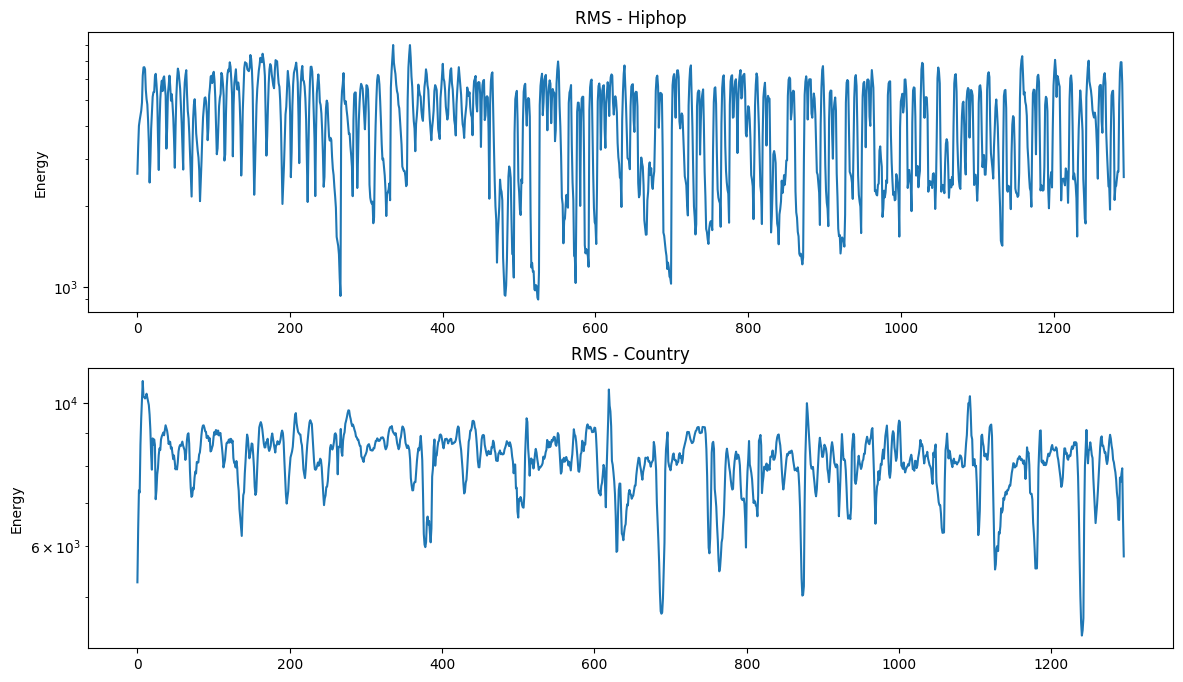

In [46]:
from IPython.display import Math, Audio
from scipy.io.wavfile import read
import numpy as np
import librosa
from librosa import frames_to_time, stft, amplitude_to_db, display
from librosa.feature import zero_crossing_rate, mfcc, spectral_bandwidth, spectral_centroid, spectral_rolloff, chroma_stft
import matplotlib.pyplot as plt
from math import ceil, log2, sqrt
from scipy import signal
from numpy import fft
from scipy.io.wavfile import read
from scipy.fftpack import fftshift
from IPython.display import Image, Audio
import matplotlib.colors as colors
from scipy.signal import stft


(country_fs, country_x) = read('../audio/country.00000.wav')
country_matrix = my_stft(x, 128, country_fs)

(hiphop_fs, hiphop_x) = read('../audio/hiphop.00000.wav')
hiphop_matrix = my_stft(x, 128, hiphop_fs)

# RMSE for hiphop
hiphop_rms = librosa.feature.rms(hiphop_x.astype(float))

# RMSE for country
country_rms = librosa.feature.rms(country_x.astype(float))

# plotting
plt.figure(figsize = (14,8))
plt.subplot(2,1,1)
plt.semilogy(hiphop_rms[0])
plt.title('RMS - Hiphop')
plt.ylabel('Energy')
plt.subplot(2,1,2)
plt.semilogy(country_rms[0])
plt.title('RMS - Country')
plt.ylabel('Energy')

Your RMSE explantion here!

/var/folders/5w/y85sjccs33v6837lhls38j4r0000gn/T/ipykernel_23934/3734153983.py:2: FutureWarning: Pass y=[-5543.  -711.   641. ...  2511.  1269.  -690.] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  hiphop_spectralcentroid = librosa.feature.spectral_centroid(hiphop_x.astype(float))
/var/folders/5w/y85sjccs33v6837lhls38j4r0000gn/T/ipykernel_23934/3734153983.py:4: FutureWarning: Pass y=[-4396. -6385. -1395. ...  7407.  4929.  1389.] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  country_spectralcentroid = librosa.feature.spectral_centroid(country_x.astype(float))


Text(0, 0.5, 'Hz')

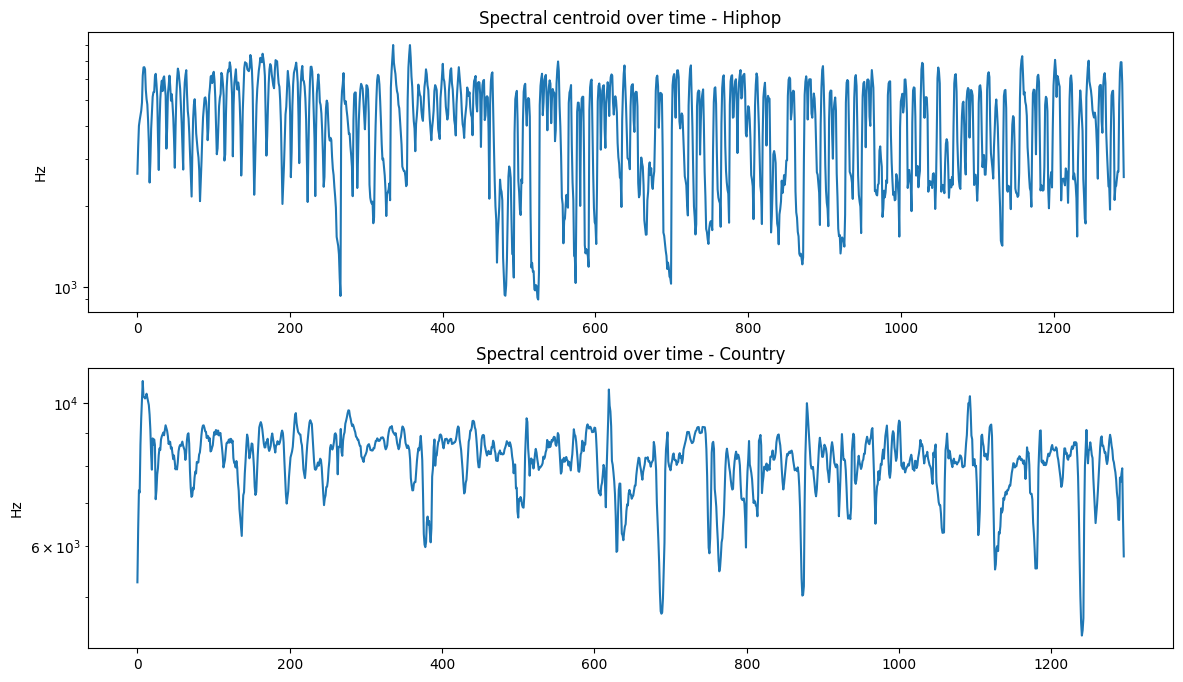

In [48]:
# Spectral Centroid for hiphop
hiphop_spectralcentroid = librosa.feature.spectral_centroid(hiphop_x.astype(float))
# Spectral Centroid for country
country_spectralcentroid = librosa.feature.spectral_centroid(country_x.astype(float))
# plotting
plt.figure(figsize = (14,8))
plt.subplot(2,1,1)
plt.semilogy(hiphop_rms[0])
plt.title('Spectral centroid over time - Hiphop')
plt.ylabel('Hz')
plt.subplot(2,1,2)
plt.semilogy(country_rms[0])
plt.title('Spectral centroid over time - Country')
plt.ylabel('Hz')

Your centroid explanation here!

Text(0, 0.5, 'Flux')

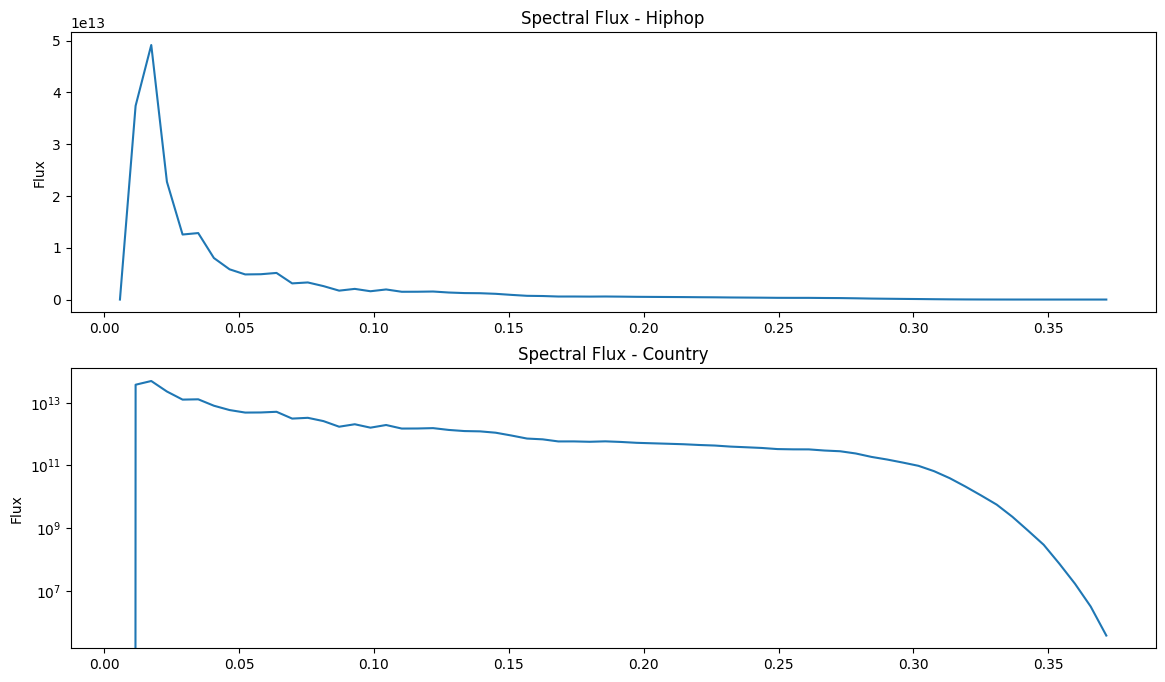

In [50]:
frame_length = 512
hop_length = 128

# spectral flux for hiphop
magnitude_hh = np.abs(hiphop_matrix)
diff_hh = np.diff(magnitude_hh, axis=1)
hiphop_flux = np.sum(diff_hh**2, axis=0)
hiphop_flux = np.concatenate(([0], hiphop_flux))
frames_hiphop= range(1,len(hiphop_flux)+1) #vector of frames as iterable
hiphop_t = frames_to_time(frames_hiphop, sr=hiphop_fs, hop_length=hop_length)

# spectral flux for country
magnitude_c = np.abs(country_matrix)
diff_c = np.diff(magnitude_c, axis=1)
country_flux = np.sum(diff_c**2, axis=0)
country_flux = np.concatenate(([0], country_flux))
frames_country= range(1,len(country_flux)+1) #vector of frames as iterable
country_t = frames_to_time(frames_country, sr=country_fs, hop_length=hop_length)

# plotting

plt.figure(figsize = (14,8))
plt.subplot(2,1,1)
plt.plot(hiphop_t, hiphop_flux)
plt.title('Spectral Flux - Hiphop')
plt.ylabel('Flux')
plt.subplot(2,1,2)
plt.semilogy(country_t, country_flux)
plt.title('Spectral Flux - Country')
plt.ylabel('Flux')

Your spectral flux explanation here!

Text(0, 0.5, 'Hz')

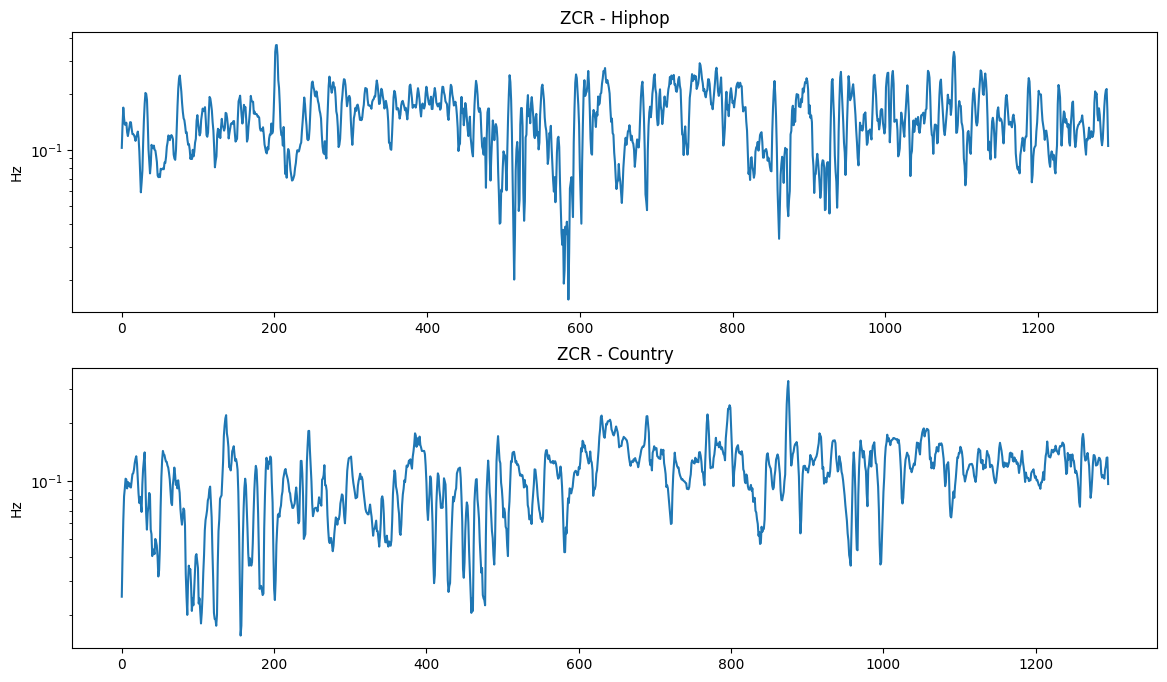

In [53]:
# ZCR for hiphop
hiphop_zcr = librosa.feature.zero_crossing_rate(hiphop_x.astype(float))
# ZCR for country
country_zcr = librosa.feature.zero_crossing_rate(country_x.astype(float))
# plotting
plt.figure(figsize = (14,8))
plt.subplot(2,1,1)
plt.semilogy(hiphop_zcr[0])
plt.title('ZCR - Hiphop')
plt.ylabel('Hz')
plt.subplot(2,1,2)
plt.semilogy(country_zcr[0])
plt.title('ZCR - Country')
plt.ylabel('Hz')

Your ZCR explanation here!

## Part 3: Binomial Logistic Regression (5 points)

Like in activity 7, you will build a binomial classifier with logistic regression. You will use the GTZAN genre dataset 'features_30_sec.csv' this time to classify hiphop vs country music.

### Explore the data and select your features (3 points)

Use graphing and correlation techniques to determine 5 features you will use for your classification.

You must at a minimum create 1 bar graph and 1 box plot in addition to computing the correlation between the features you select.

Construct your Pandas dataframe for your chosen features. Remember you may want to do some scaling and normalization.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split



### Train/Test Split

Use sklearn to split your data into testing and training sets. Remember you will need to define your categories, predictors, and test size. Use 30% test size.

### Train the Model and Evaluate (2 points)

Train the model using logistic regression.

Calculate the confusion matrix (and view as a data frame). Calculate the accuracy, precision, recall, and F1 scores.

Explain what the confusion matrix and accuracy tell us about your model.

Your model interpretation here!

GenAI Usage Statement:

- Tool used and date of access
- The input (prompt) you provided
- A copy of the output
- A description of how you used or edited the AI-generated content